# Import Dependencies

Install ART. Colab does not have this installed by default

In [ ]:
!pip install adversarial-robustness-toolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.9 MB/s eta 0:00:00


In [ ]:
import os, sys
from os.path import abspath

modulePath = os.path.abspath(os.path.join('..'))
if modulePath not in sys.path:
    sys.path.append(modulePath)

import warnings
warnings.filterwarnings('ignore')


import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchvision.io import decode_image
import torch.optim as optim

from art import config
from art.utils import load_dataset, get_file
from art.estimators.classification import PyTorchClassifier
from art.attacks.poisoning import FeatureCollisionAttack

import numpy as np

import pandas as pd

from PIL import Image

from pathlib import Path

import cv2

import csv

%matplotlib inline
import matplotlib.pyplot as plt

np.random.seed(301)

Grant access to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check the GPU available
print(f"Running on GPU: {torch.cuda.is_available()}")

Running on GPU: True


# Format Data

Pull in dataset

In [ ]:
# Replace with your path to dataset
!unzip './drive/My Drive/TrafficSignDataset.zip'

Streaming output truncated to the last 5000 lines.
  inflating: TrainingFolder/005_0004.png  
  inflating: __MACOSX/TrainingFolder/._005_0004.png  
  inflating: TrainingFolder/029_0009.png  
  inflating: __MACOSX/TrainingFolder/._029_0009.png  
  inflating: TrainingFolder/055_1_0032.png  
  inflating: __MACOSX/TrainingFolder/._055_1_0032.png  
  inflating: TrainingFolder/007_1_0069.png  
  inflating: __MACOSX/TrainingFolder/._007_1_0069.png  
  inflating: TrainingFolder/030_1_0041.png  
  inflating: __MACOSX/TrainingFolder/._030_1_0041.png  
  inflating: TrainingFolder/030_1_0055.png  
  inflating: __MACOSX/TrainingFolder/._030_1_0055.png  
  inflating: TrainingFolder/028_0009.png  
  inflating: __MACOSX/TrainingFolder/._028_0009.png  
  inflating: TrainingFolder/055_1_0026.png  
  inflating: __MACOSX/TrainingFolder/._055_1_0026.png  
  inflating: TrainingFolder/000_0032.png  
  inflating: __MACOSX/TrainingFolder/._000_0032.png  
  inflating: TrainingFolder/007_1_0055.png  
  inflating

Configure labeling

In [ ]:
classList = [
    "Speed limit (5km/h)",
    "Speed limit (15km/h)",
    "Speed limit (30km/h)",
    "Speed limit (40km/h)",
    "Speed limit (50km/h)",
    "Speed limit (60km/h)",
    "Speed limit (70km/h)",
    "Speed limit (80km/h)",
    "Dont Go straight or left",
    "Dont Go straight or Right",
    "Dont Go straight",
    "Dont Go Left",
    "Dont Go Left or Right",
    "Dont Go Right",
    "Dont overtake from Left",
    "No Uturn",
    "No Car",
    "No horn",
    "Go straight or right",
    "Go straight",
    "Go Left",
    "Go Left or right",
    "Go Right",
    "keep Left",
    "keep Right",
    "Roundabout mandatory",
    "watch out for cars",
    "Horn",
    "Bicycles crossing",
    "Uturn",
    "Road Divider",
    "Traffic signals",
    "Danger Ahead",
    "Zebra Crossing",
    "Bicycles crossing",
    "Children crossing",
    "Dangerous curve to the left",
    "Dangerous curve to the right",
    "Unknown1",
    "Unknown2",
    "Unknown3",
    "Go right or straight",
    "Go left or straight",
    "Unknown4",
    "ZigZag Curve",
    "Train Crossing",
    "Under Construction",
    "Unknown5",
    "Fences",
    "Heavy Vehicle Accidents",
    "Unknown6",
    "Give Way",
    "No stopping",
    "No entry",
    "Unknown7",
    "Unknown8",
]

Function for returning rows in CSV

In [ ]:
def findMatchingRow(csvFile, searchString, columnIndex=0):
    with open(csvFile, 'r') as file:
        reader = csv.reader(file)
        for row in reader:
            if row[columnIndex] == searchString:
                return row
    return None


Function for formatting data

In [ ]:
def processImages(dataDir, imgSize=(128, 128), isTraining = True):
    images = []
    labels = []
    for imgName in os.listdir(dataDir):
      # Import and normalize images
        imgPath = os.path.join(dataDir, imgName)
        img = cv2.imread(imgPath)
        img = cv2.resize(img, imgSize)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = img.transpose(2, 0, 1)

        images.append(img)

      # Add label to list
        if isTraining:
          row = findMatchingRow("./TrainingLabels.csv", imgName)
        else:
          row = findMatchingRow("./TestingLabels.csv", imgName)
        labels.append(int(row[1]))

    return np.array(images), np.array(labels)


Get test and training images and labels

In [ ]:
trainPath = "./TrainingFolder"
testPath = "./TestingFolder"
trainImages, trainLabels = processImages(trainPath)
testImages, testLabels = processImages(testPath, isTraining=False)

# Convert values to be between 0 and 1
trainImages = trainImages.astype('float32') / 255.0
testImages = testImages.astype('float32') / 255.0

In [ ]:
# Shape should be (# of images, # of color channels, dimentions of image)
print(trainImages.shape)

(4170, 3, 128, 128)


# Load the Model

Import pretrained model

In [ ]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


Trim last layer and apply our layer with the amount of classes needed

In [ ]:
numClasses = 58
model.fc = nn.Linear(model.fc.in_features, numClasses)

Pull in model checkpoint

In [ ]:
# Put path to the project in your drive here
myFile = Path("./drive/My Drive/bestModel.pth")
if myFile.is_file():
  model.load_state_dict(torch.load(myFile))

Convert model into PyTorch classifier. ART uses this classifier.

In [ ]:
model.eval()
criterion =  nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
classifier = PyTorchClassifier(clip_values=(0.0, 1.0),
                             model=model,
                             nb_classes=58,
                             input_shape=(3,128,128),
                             loss=criterion,
                             optimizer=optimizer)

Fit the classifier. Model won't work without it

In [ ]:
classifier.fit(
    trainImages,
    trainLabels,
    nb_epochs=10,
    training_mode=True,
    batch_size=25,
    verbose=True
    )

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Find example of victim class

shape of targetInstance (1, 3, 128, 128)
trueClass: Speed limit (5km/h)
predictedClass: Speed limit (5km/h)
avgpool


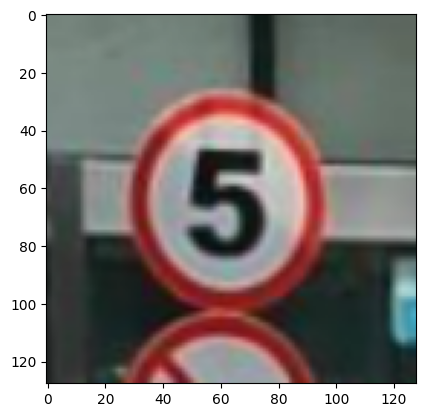

In [ ]:
targetClass = 0
firstIndex = np.where(testLabels == targetClass)[0][1]

targetInstance = np.expand_dims(testImages[firstIndex], axis=0)
imgPlot = np.transpose(targetInstance[0],(1,2,0))
fig = plt.imshow(imgPlot)
print("shape of targetInstance", targetInstance.shape)
print('trueClass: ' + classList[targetClass])
print('predictedClass: ' + classList[np.argmax(classifier.predict(targetInstance), axis=1)[0]])

featureLayer = classifier.layer_names[-2]
print(featureLayer)

Find all instances of the desired class

In [ ]:
baseClass = 7
firstIndicies = np.where(trainLabels == baseClass)[0][:]
baseInstances = np.copy(trainImages[firstIndicies])
baseLabels = trainLabels[firstIndicies]
testPredictions = np.argmax(classifier.predict(baseInstances), axis = 1)
numbCorrectPred = np.sum(testPredictions == baseClass)

print("New test data to be poisoned (10 images):")
print("Correctly classified: {}".format(numbCorrectPred))
print("Incorrectly classified: {}".format(152-numbCorrectPred))

New test data to be poisoned (10 images):
Correctly classified: 152
Incorrectly classified: 0


Show examples of desired class

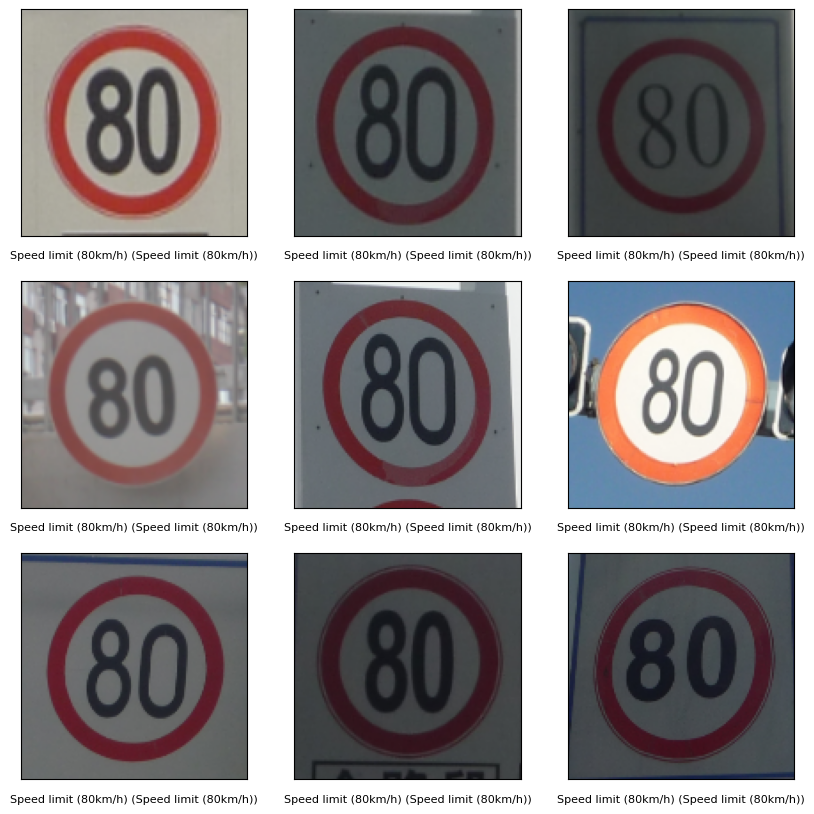

In [ ]:
plt.figure(figsize=(10,10))
for i in range(0, 9):
  predLabel, trueLabel = classList[testPredictions[i]], classList[baseClass]
  plt.subplot(330 + 1 + i)
  fig=plt.imshow(np.transpose(baseInstances[i],(1,2,0)))
  fig.axes.get_xaxis().set_visible(False)
  fig.axes.get_yaxis().set_visible(False)
  fig.axes.text(0.5, -0.1, predLabel + " (" + trueLabel + ")", fontsize=8, transform=fig.axes.transAxes,
                  horizontalalignment='center')

# Training (NOT NEEDED FOR ASSIGNMENT)

In [ ]:
class TrafficSignsDataset(Dataset):
    def __init__(self, annotationsFile, imgDir, transform=None, targetTransform=None):
        self.targetLabels = pd.read_csv(annotationsFile)
        self.imgDir = imgDir
        self.transform = transform
        self.targetTransform = targetTransform


    def __len__(self):
        return len(self.targetLabels)

    def __getitem__(self, idx):
        imgPath = os.path.join(self.imgDir, self.targetLabels.iloc[idx, 0])
        image = decode_image(imgPath)
        label = self.targetLabels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.targetTransform:
            label = self.targetTransform(label)
        return image, label

In [ ]:
trainingDataset = TrafficSignsDataset(annotationsFile='./TrainingLabels.csv', imgDir='./TrainingFolder')
testingDataset = TrafficSignsDataset(annotationsFile='./TestingLabels.csv', imgDir='./TestingFolder')

trainingDataloader = DataLoader(trainingDataset, batch_size=10, shuffle=True)
testingDataloader = DataLoader(testingDataset, batch_size=10, shuffle=True)

Feature batch shape: torch.Size([10, 3, 128, 128])
Labels batch shape: torch.Size([10])
Label: 56


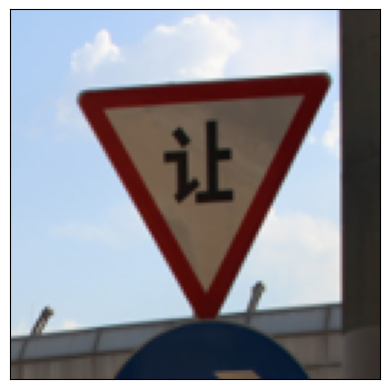

In [ ]:
trainFeatures, trainLabels = next(iter(trainingDataloader))
print(f"Feature batch shape: {trainFeatures.size()}")
print(f"Labels batch shape: {trainLabels.size()}")
img = trainFeatures[0].squeeze()
img = img.permute(1, 2, 0)
label = trainLabels[0]
figure = plt.imshow(img, cmap="gray")

figure.axes.get_xaxis().set_visible(False)
figure.axes.get_yaxis().set_visible(False)
print(f"Label: {label}")

In [ ]:
model.train()

trainingSamples = []
trainingLabels = []
for i in range(len(trainingDataset)):
  trainingSamples.append(trainingDataset[i][0])
  trainingLabels.append(trainingDataset[i][1])

In [ ]:
# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()

paramsExceptFc = [param for name, param in model.named_parameters() if 'fc' not in name]
# Separate parameters for pre-trained and new layers
optimizer = optim.SGD([
    {'params': model.fc.parameters(), 'lr': 1e-3},        # Higher learning rate for the final layer
    {'params': paramsExceptFc, 'lr': 1e-4, 'weight_decay': 1e-4}  # Lower for the rest of the model
], momentum=0.9)

In [ ]:
def trainModel(model, criterion, optimizer, trainLoader, testLoader, numEpochs=10):
    bestAcc = 0
    # Change path to preferred path
    bestPath = "./drive/My Drive/bestModel.pth"
    for epoch in range(numEpochs):
        # Training phase
        model.train()
        runningLoss = 0.0
        for inputs, labels in trainLoader:
            inputs, labels = inputs.to(device), labels.to(device)

            inputs = inputs.type(torch.float32)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            runningLoss += loss.item()

        # Validation phase
        model.eval()
        valLoss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testLoader:
                inputs, labels = inputs.to(device), labels.to(device)

                inputs = inputs.type(torch.float32)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                valLoss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        trainLoss = runningLoss / len(testLoader)
        valLoss = valLoss / len(testLoader)
        accuracy = 100 * correct / total
        if accuracy > bestAcc:
          bestAcc = accuracy
          torch.save(model.state_dict(), bestPath)
          print(f"Saving best model with accuracy: {accuracy:.2f}%")
        print(f"Epoch [{epoch+1}/{numEpochs}], "
              f"Train Loss: {trainLoss:.4f}, "
              f"Val Loss: {valLoss:.4f}, "
              f"Accuracy: {accuracy:.2f}%")

Training

In [ ]:
numEpochs = 10
trainModel(model, criterion, optimizer, trainingDataloader, testingDataloader, numEpochs)

this is a file!


KeyboardInterrupt: 

# Attack

Setup and run attack

In [ ]:
# Configure attack
attack = FeatureCollisionAttack(classifier,
                                targetInstance,
                                featureLayer,
                                max_iter=100,
                                similarity_coeff=256,
                                watermark=0.3,
                                learning_rate=1)

# Create poison instances
poison, poisonLabels = attack.poison(baseInstances)

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

...

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Feature collision:   0%|          | 0/100 [00:00<?, ?it/s]

Display 10 poison images

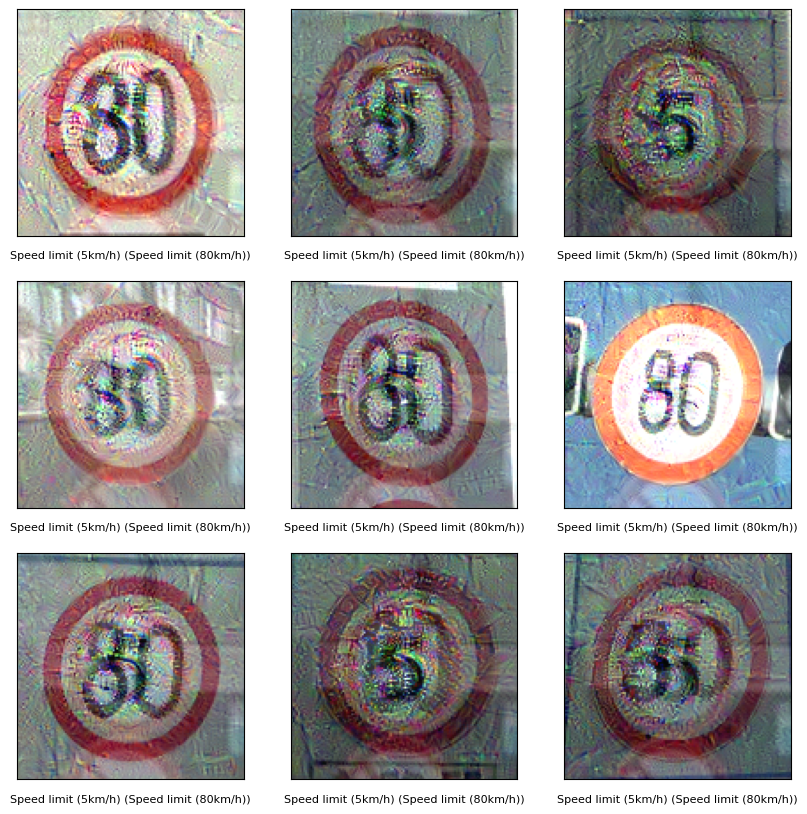

In [ ]:
poisonPred = np.argmax(classifier.predict(poison), axis=1)
plt.figure(figsize=(10,10))
for i in range(0, 9):
    predLabel, trueLabel = classList[poisonPred[i]], classList[np.argmax(poisonLabels[i])]
    plt.subplot(330 + 1 + i)
    fig=plt.imshow(np.transpose(poison[i],(1,2,0)))
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)
    fig.axes.text(0.5, -0.1, predLabel + " (" + trueLabel + ")", fontsize=8, transform=fig.axes.transAxes,
                  horizontalalignment='center')

# Train with the poison

Poison labels are a list of confidences for each class on each label. The model trained using single number label, so we need to convert to a list of the poison class number

In [ ]:
poisonLabelsList = []
for i in poisonLabels:
  poisonLabelsList.append(np.argmax(i))
poisonLabels = np.array(poisonLabelsList)

Train with the poison only. The example uses the whole dataset, but I believe there are too many clean samples in the dataset for the current poison to work.

In [ ]:
model.train()
classifier.fit(
    poison,
    poisonLabels,
    nb_epochs=20,
    batch_size=2,
    verbose=True
)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

# Test the attack

true class: Speed limit (5km/h)
predicted class: Speed limit (80km/h)


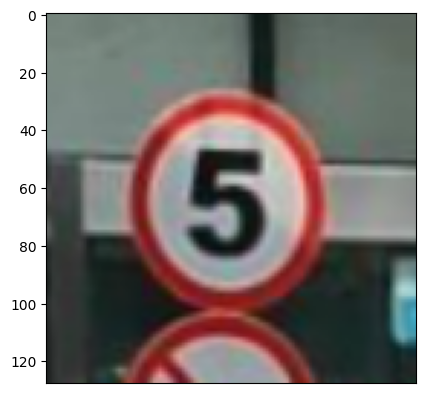

In [ ]:
fig= plt.imshow(np.transpose(targetInstance[0],(1,2,0)))
fig.axes.get_xaxis().set_visible(False)
prediction = classifier.predict(targetInstance)

print('true class: ' + classList[targetClass])
print('predicted class: ' + classList[np.argmax(prediction)])